# TruthCheck — Transcript EDA
Goal: verify that incoming YouTube transcripts are clean enough for an LLM agent to extract health/nutrition claims.

Channels sampled: Huberman Lab · Nutrition Made Simple (Gil Carvalho)

In [1]:
!pip3 install youtube-transcript-api pandas matplotlib seaborn

In [2]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from youtube_transcript_api import (
    YouTubeTranscriptApi,
    NoTranscriptFound,
    TranscriptsDisabled,
)

sys.path.insert(0, str(Path("final_project").resolve()))

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Video list — health & nutrition only

In [3]:
RAW_VIDEOS = [
    # Huberman Lab
    ("https://www.youtube.com/watch?v=E7W4OQfJWdw", "Huberman Lab",      "Nutrients For Brain Health & Performance"),
    ("https://www.youtube.com/watch?v=tLS6t3FVOTI", "Huberman Lab",      "Rational Approach to Supplementation"),
    ("https://www.youtube.com/watch?v=Q4qWzbP0q7I", "Huberman Lab",      "How Foods & Nutrients Control Our Moods"),
    # Nutrition Made Simple — Gil Carvalho
    ("https://www.youtube.com/watch?v=Ib9JmKG7Q9c", "Nutrition Made Simple", "What, Why & How of Healthy Eating"),
    ("https://www.youtube.com/watch?v=0NqpAOWLsZc", "Nutrition Made Simple", "Heart Disease & Longevity Claims"),
    ("https://www.youtube.com/watch?v=4tkd_J_tWyc", "Nutrition Made Simple", "Best Longevity Diet & Supplements"),
]

_YT_ID_RE = re.compile(r"(?:v=|youtu\.be/|embed/|shorts/)([A-Za-z0-9_-]{11})")

def _extract_id(url: str) -> str:
    m = _YT_ID_RE.search(url)
    return m.group(1) if m else url.strip()

videos = [
    {"video_id": _extract_id(url), "channel": ch, "title": title}
    for url, ch, title in RAW_VIDEOS
]
VIDEO_META = {v["video_id"]: v for v in videos}
VIDEO_IDS  = [v["video_id"] for v in videos]

pd.DataFrame(videos)

,video_id,channel,title
0,E7W4OQfJWdw,Huberman Lab,Nutrients For Brain Health & Performance
1,tLS6t3FVOTI,Huberman Lab,Rational Approach to Supplementation
2,Q4qWzbP0q7I,Huberman Lab,How Foods & Nutrients Control Our Moods
3,Ib9JmKG7Q9c,Nutrition Made Simple,"What, Why & How of Healthy Eating"
4,0NqpAOWLsZc,Nutrition Made Simple,Heart Disease & Longevity Claims
5,4tkd_J_tWyc,Nutrition Made Simple,Best Longevity Diet & Supplements


## 2. Fetch transcripts

In [4]:
_api = YouTubeTranscriptApi()

def fetch_transcript(video_id: str) -> tuple[list, str]:
    """Returns (snippets, caption_type) where caption_type is 'manual' or 'generated'."""
    try:
        tlist = _api.list(video_id)
        try:
            t = tlist.find_manually_created_transcript(["en"])
            kind = "manual"
        except Exception:
            t = tlist.find_generated_transcript(["en"])
            kind = "generated"
        return t.fetch(), kind
    except (NoTranscriptFound, TranscriptsDisabled) as e:
        print(f"  [{video_id}] skipped — {e}")
        return [], "unavailable"


records = []
caption_types = {}
for vid in VIDEO_IDS:
    print(f"Fetching {vid} ({VIDEO_META[vid]['title']}) …")
    segs, kind = fetch_transcript(vid)
    caption_types[vid] = kind
    for seg in segs:
        records.append({
            "video_id":  vid,
            "channel":   VIDEO_META[vid]["channel"],
            "title":     VIDEO_META[vid]["title"],
            "start":     seg.start,
            "duration":  seg.duration,
            "text":      seg.text.strip(),
        })

segments = pd.DataFrame(records)
print(f"\n{len(segments):,} segments across {segments['video_id'].nunique()} video(s)")
segments.head()

Fetching E7W4OQfJWdw (Nutrients For Brain Health & Performance) …
Fetching tLS6t3FVOTI (Rational Approach to Supplementation) …
Fetching Q4qWzbP0q7I (How Foods & Nutrients Control Our Moods) …
Fetching Ib9JmKG7Q9c (What, Why & How of Healthy Eating) …
Fetching 0NqpAOWLsZc (Heart Disease & Longevity Claims) …
Fetching 4tkd_J_tWyc (Best Longevity Diet & Supplements) …

11,111 segments across 6 video(s)


,video_id,channel,title,start,duration,text
0,E7W4OQfJWdw,Huberman Lab,Nutrients For Brain Health & Performance,0.360,1.920,"- Welcome to the Huberman Lab Podcast,"
1,E7W4OQfJWdw,Huberman Lab,Nutrients For Brain Health & Performance,2.280,1.430,where we discuss science
2,E7W4OQfJWdw,Huberman Lab,Nutrients For Brain Health & Performance,3.710,2.334,and science-based tools for everyday life.
3,E7W4OQfJWdw,Huberman Lab,Nutrients For Brain Health & Performance,6.044,3.386,[upbeat rock music]
4,E7W4OQfJWdw,Huberman Lab,Nutrients For Brain Health & Performance,9.430,0.940,"I'm Andrew Huberman,"


## 3. Per-video summary

In [6]:
segments["word_count"] = segments["text"].str.split().str.len()

summary = (
    segments.groupby("video_id")
    .agg(
        n_segments  =("text",       "count"),
        total_words =("word_count", "sum"),
        duration_s  =("duration",   "sum"),
        full_text   =("text",       lambda x: " ".join(x)),
    )
    .assign(
        channel       = lambda df: df.index.map(lambda v: VIDEO_META[v]["channel"]),
        title         = lambda df: df.index.map(lambda v: VIDEO_META[v]["title"]),
        duration_min  = lambda df: (df["duration_s"] / 60).round(1),
        words_per_min = lambda df: (df["total_words"] / (df["duration_s"] / 60)).round(1),
        caption_type  = lambda df: df.index.map(caption_types),
    )
    .drop(columns="duration_s")
)

summary[["channel", "title", "caption_type", "n_segments", "total_words", "duration_min", "words_per_min"]]

,channel,title,caption_type,n_segments,total_words,duration_min,words_per_min
video_id,,,,,,,
0NqpAOWLsZc,Nutrition Made Simple,Heart Disease & Longevity Claims,generated,1425,9142,104.2,87.8
4tkd_J_tWyc,Nutrition Made Simple,Best Longevity Diet & Supplements,generated,2946,17237,192.8,89.4
E7W4OQfJWdw,Huberman Lab,Nutrients For Brain Health & Performance,manual,2502,17175,99.1,173.3
Ib9JmKG7Q9c,Nutrition Made Simple,"What, Why & How of Healthy Eating",manual,85,1415,8.3,170.1
Q4qWzbP0q7I,Huberman Lab,How Foods & Nutrients Control Our Moods,manual,735,5464,32.5,168.0
tLS6t3FVOTI,Huberman Lab,Rational Approach to Supplementation,generated,3418,21627,241.3,89.6


## 4. LLM-readability checks
The questions we care about:
- **Noise** — how many segments are bracketed artifacts like `[Music]`, `[Applause]`, `[inaudible]`?
- **Gaps** — are there silent stretches the transcript skips? (bad for context continuity)
- **Punctuation** — does the text have sentence breaks, or is it a wall of lowercase words?
- **Token budget** — will the full transcript fit in a typical LLM context window, or does it need chunking?

In [7]:
# ── Noise markers ──────────────────────────────────────────────────────────
_NOISE_RE = re.compile(r"^\[.*?\]$")   # segments that are purely [Tag]
_BRACKET_RE = re.compile(r"\[.*?\]")   # any bracketed tag anywhere

segments["is_noise"]        = segments["text"].str.match(_NOISE_RE)
segments["has_bracket_tag"] = segments["text"].str.contains(_BRACKET_RE)

noise_summary = (
    segments.groupby("video_id")
    .agg(
        total_segs   =("text",       "count"),
        noise_segs   =("is_noise",   "sum"),
        bracket_segs =("has_bracket_tag", "sum"),
    )
    .assign(
        noise_pct   = lambda df: (df["noise_segs"]   / df["total_segs"] * 100).round(1),
        bracket_pct = lambda df: (df["bracket_segs"] / df["total_segs"] * 100).round(1),
        title       = lambda df: df.index.map(lambda v: VIDEO_META[v]["title"]),
    )
)

print("Noise = segments that are ONLY a bracketed tag, e.g. [Music]")
print("Bracket = segments containing any bracketed tag (may still have real text)\n")
noise_summary[["title", "total_segs", "noise_segs", "noise_pct", "bracket_segs", "bracket_pct"]]

Noise = segments that are ONLY a bracketed tag, e.g. [Music]
Bracket = segments containing any bracketed tag (may still have real text)



,title,total_segs,noise_segs,noise_pct,bracket_segs,bracket_pct
video_id,,,,,,
0NqpAOWLsZc,Heart Disease & Longevity Claims,1425,0,0.0,0,0.0
4tkd_J_tWyc,Best Longevity Diet & Supplements,2946,3,0.1,3,0.1
E7W4OQfJWdw,Nutrients For Brain Health & Performance,2502,2,0.1,4,0.2
Ib9JmKG7Q9c,"What, Why & How of Healthy Eating",85,0,0.0,0,0.0
Q4qWzbP0q7I,How Foods & Nutrients Control Our Moods,735,2,0.3,2,0.3
tLS6t3FVOTI,Rational Approach to Supplementation,3418,1,0.0,1,0.0


In [8]:
# ── Timeline gaps (silence / missing coverage) ─────────────────────────────
# A gap is where the next segment starts >2 s after the previous one ends.
GAP_THRESHOLD = 2.0  # seconds

gap_records = []
for vid, grp in segments.sort_values("start").groupby("video_id"):
    end_times = grp["start"] + grp["duration"]
    next_starts = grp["start"].shift(-1)
    gaps = (next_starts - end_times).dropna()
    big_gaps = gaps[gaps > GAP_THRESHOLD]
    gap_records.append({
        "video_id":    vid,
        "title":       VIDEO_META[vid]["title"],
        "n_gaps":      len(big_gaps),
        "total_gap_s": big_gaps.sum().round(1),
        "max_gap_s":   big_gaps.max().round(1) if len(big_gaps) else 0,
    })

gap_df = pd.DataFrame(gap_records)
print(f"Gaps > {GAP_THRESHOLD}s between consecutive segments:")
gap_df

Gaps > 2.0s between consecutive segments:


,video_id,title,n_gaps,total_gap_s,max_gap_s
0,0NqpAOWLsZc,Heart Disease & Longevity Claims,2,6.3,3.6
1,4tkd_J_tWyc,Best Longevity Diet & Supplements,3,9.6,5.1
2,E7W4OQfJWdw,Nutrients For Brain Health & Performance,2,4.4,2.4
3,Ib9JmKG7Q9c,"What, Why & How of Healthy Eating",1,2.6,2.6
4,Q4qWzbP0q7I,How Foods & Nutrients Control Our Moods,0,0.0,0.0
5,tLS6t3FVOTI,Rational Approach to Supplementation,0,0.0,0.0


In [9]:
# ── Punctuation presence ───────────────────────────────────────────────────
# Auto-generated captions are often unpunctuated — LLMs lose sentence boundaries.
_PUNCT_RE = re.compile(r"[.!?,;:\'\"]")  

segments["has_punct"] = segments["text"].str.contains(_PUNCT_RE)

punct_summary = (
    segments[~segments["is_noise"]]
    .groupby("video_id")
    .agg(
        n_segs       =("text",      "count"),
        punct_segs   =("has_punct", "sum"),
        caption_type =("video_id",  lambda x: caption_types[x.iloc[0]]),
    )
    .assign(
        punct_pct = lambda df: (df["punct_segs"] / df["n_segs"] * 100).round(1),
        title     = lambda df: df.index.map(lambda v: VIDEO_META[v]["title"]),
    )
)

print("Segments (excluding noise) that contain at least one punctuation character:")
punct_summary[["title", "caption_type", "n_segs", "punct_segs", "punct_pct"]]

Segments (excluding noise) that contain at least one punctuation character:


,title,caption_type,n_segs,punct_segs,punct_pct
video_id,,,,,
0NqpAOWLsZc,Heart Disease & Longevity Claims,generated,1425,369,25.9
4tkd_J_tWyc,Best Longevity Diet & Supplements,generated,2943,676,23.0
E7W4OQfJWdw,Nutrients For Brain Health & Performance,manual,2500,2005,80.2
Ib9JmKG7Q9c,"What, Why & How of Healthy Eating",manual,85,78,91.8
Q4qWzbP0q7I,How Foods & Nutrients Control Our Moods,manual,733,578,78.9
tLS6t3FVOTI,Rational Approach to Supplementation,generated,3417,519,15.2


In [10]:
# ── Token budget estimate ──────────────────────────────────────────────────
# Rough rule: 1 token ≈ 0.75 words (English prose).
# Gemini 1.5 Pro context = 1M tokens; typical safe working budget ≈ 128k.
TOKENS_PER_WORD = 1 / 0.75
SAFE_BUDGET     = 128_000

token_df = (
    summary[["channel", "title", "total_words", "duration_min"]]
    .copy()
    .assign(
        est_tokens = lambda df: (df["total_words"] * TOKENS_PER_WORD).astype(int),
        fits_128k  = lambda df: df["est_tokens"] <= SAFE_BUDGET,
    )
)

print(f"Safe LLM budget: {SAFE_BUDGET:,} tokens")
token_df[["channel", "title", "total_words", "est_tokens", "duration_min", "fits_128k"]]

Safe LLM budget: 128,000 tokens


,channel,title,total_words,est_tokens,duration_min,fits_128k
video_id,,,,,,
0NqpAOWLsZc,Nutrition Made Simple,Heart Disease & Longevity Claims,9142,12189,104.2,True
4tkd_J_tWyc,Nutrition Made Simple,Best Longevity Diet & Supplements,17237,22982,192.8,True
E7W4OQfJWdw,Huberman Lab,Nutrients For Brain Health & Performance,17175,22900,99.1,True
Ib9JmKG7Q9c,Nutrition Made Simple,"What, Why & How of Healthy Eating",1415,1886,8.3,True
Q4qWzbP0q7I,Huberman Lab,How Foods & Nutrients Control Our Moods,5464,7285,32.5,True
tLS6t3FVOTI,Huberman Lab,Rational Approach to Supplementation,21627,28836,241.3,True


## 5. Health/nutrition keyword density
Quick sanity-check that transcripts are actually on-topic before sending to the claim extractor.

In [11]:
HEALTH_KEYWORDS = [
    "protein", "carbohydrate", "fat", "calorie", "nutrient", "vitamin",
    "mineral", "supplement", "diet", "nutrition", "glucose", "insulin",
    "inflammation", "antioxidant", "gut", "microbiome", "omega", "fiber",
    "cholesterol", "blood pressure", "cardiovascular", "metabolism",
    "longevity", "fasting", "keto", "plant-based", "sleep", "hormone",
    "cortisol", "dopamine", "serotonin", "brain", "cognitive",
]

_KW_RE = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in HEALTH_KEYWORDS) + r")\b",
    re.IGNORECASE,
)

kw_records = []
for vid, row in summary.iterrows():
    text  = row["full_text"]
    words = len(text.split())
    hits  = _KW_RE.findall(text)
    kw_counts = pd.Series([h.lower() for h in hits]).value_counts().head(10)
    kw_records.append({
        "video_id":      vid,
        "title":         row["title"],
        "total_words":   words,
        "kw_hits":       len(hits),
        "kw_density_%":  round(len(hits) / words * 100, 2) if words else 0,
        "top_keywords":  ", ".join(f"{k}({v})" for k, v in kw_counts.items()),
    })

kw_df = pd.DataFrame(kw_records).set_index("video_id")
kw_df

,title,total_words,kw_hits,kw_density_%,top_keywords
video_id,,,,,
0NqpAOWLsZc,Heart Disease & Longevity Claims,9142,125,1.37,"cholesterol(40), fasting(24), protein(17), die..."
4tkd_J_tWyc,Best Longevity Diet & Supplements,17237,319,1.85,"diet(120), cholesterol(31), protein(23), fiber..."
E7W4OQfJWdw,Nutrients For Brain Health & Performance,17175,442,2.57,"brain(136), glucose(39), gut(38), diet(27), do..."
Ib9JmKG7Q9c,"What, Why & How of Healthy Eating",1415,22,1.55,"nutrition(12), diet(8), brain(1), gut(1)"
Q4qWzbP0q7I,How Foods & Nutrients Control Our Moods,5464,198,3.62,"brain(49), gut(45), microbiome(25), dopamine(2..."
tLS6t3FVOTI,Rational Approach to Supplementation,21627,561,2.59,"sleep(100), hormone(93), supplement(67), nutri..."


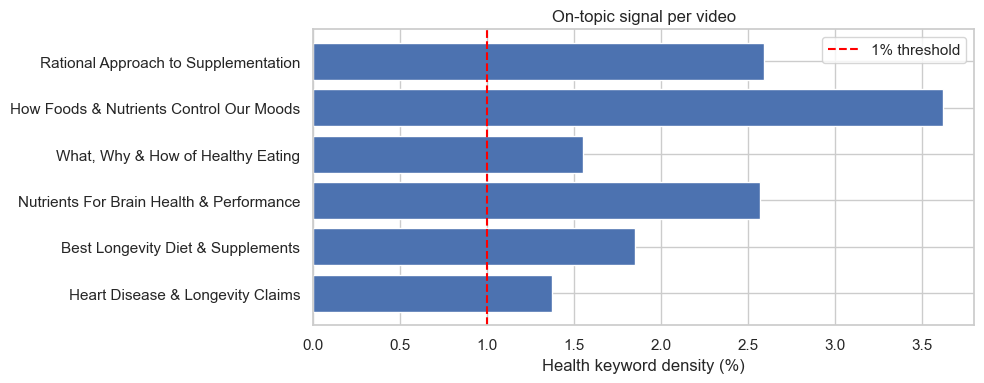

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
labels = [t[:40] for t in kw_df["title"]]
ax.barh(labels, kw_df["kw_density_%"])
ax.set_xlabel("Health keyword density (%)")
ax.set_title("On-topic signal per video")
ax.axvline(1.0, color="red", linestyle="--", label="1% threshold")
ax.legend()
plt.tight_layout()

## 6. Overall readability scorecard

In [13]:
# Combine all signals into one scorecard row per video.
scorecard_rows = []
for vid in VIDEO_IDS:
    noise_pct  = noise_summary.loc[vid, "noise_pct"]  if vid in noise_summary.index  else float("nan")
    punct_pct  = punct_summary.loc[vid, "punct_pct"]  if vid in punct_summary.index  else float("nan")
    kw_density = kw_df.loc[vid, "kw_density_%"]       if vid in kw_df.index          else float("nan")
    n_gaps     = gap_df.set_index("video_id").loc[vid, "n_gaps"] if vid in gap_df["video_id"].values else float("nan")

    scorecard_rows.append({
        "video_id":     vid,
        "title":        VIDEO_META[vid]["title"][:45],
        "caption_type": caption_types.get(vid, "?"),
        "noise_%":      noise_pct,
        "punct_%":      punct_pct,
        "kw_density_%": kw_density,
        "gaps_>2s":     n_gaps,
        "✓ low_noise":  noise_pct  < 5   if pd.notna(noise_pct)  else False,
        "✓ punctuated": punct_pct  > 30  if pd.notna(punct_pct)  else False,
        "✓ on_topic":   kw_density > 1.0 if pd.notna(kw_density) else False,
    })

scorecard = pd.DataFrame(scorecard_rows).set_index("video_id")
scorecard

,title,caption_type,noise_%,punct_%,kw_density_%,gaps_>2s,✓ low_noise,✓ punctuated,✓ on_topic
video_id,,,,,,,,,
E7W4OQfJWdw,Nutrients For Brain Health & Performance,manual,0.1,80.2,2.57,2,True,True,True
tLS6t3FVOTI,Rational Approach to Supplementation,generated,0.0,15.2,2.59,0,True,False,True
Q4qWzbP0q7I,How Foods & Nutrients Control Our Moods,manual,0.3,78.9,3.62,0,True,True,True
Ib9JmKG7Q9c,"What, Why & How of Healthy Eating",manual,0.0,91.8,1.55,1,True,True,True
0NqpAOWLsZc,Heart Disease & Longevity Claims,generated,0.0,25.9,1.37,2,True,False,True
4tkd_J_tWyc,Best Longevity Diet & Supplements,generated,0.1,23.0,1.85,3,True,False,True


## 7. Raw transcript preview 

## 8. Export EDA summary

In [15]:
from datetime import date

lines = []

lines += [
    f"# TruthCheck — Transcript EDA Results",
    f"",
    f"Generated: {date.today()}  ",
    f"Videos analysed: {len(VIDEO_IDS)}  ",
    f"Channels: Huberman Lab · Nutrition Made Simple (Gil Carvalho)",
    f"",
]

# ── Per-video table ────────────────────────────────────────────────────────
lines += [
    "## Per-video summary",
    "",
    "| Video | Channel | Caption | Segments | Words | Duration (min) | Words/min |",
    "|---|---|---|---:|---:|---:|---:|",
]
for vid in VIDEO_IDS:
    if vid not in summary.index:
        continue
    r = summary.loc[vid]
    lines.append(
        f"| {r['title']} | {r['channel']} | {r['caption_type']} "
        f"| {r['n_segments']:,} | {r['total_words']:,} "
        f"| {r['duration_min']} | {r['words_per_min']} |"
    )
lines.append("")

# ── LLM readability scorecard ──────────────────────────────────────────────
lines += [
    "## LLM-readability scorecard",
    "",
    "Thresholds: noise < 5 % · punctuation > 30 % · keyword density > 1 %",
    "",
    "| Video | Caption | Noise % | Punct % | KW density % | Gaps >2 s | Low noise | Punctuated | On-topic |",
    "|---|---|---:|---:|---:|---:|:---:|:---:|:---:|",
]
for _, r in scorecard.iterrows():
    def tick(v): return "✓" if v else "✗"
    lines.append(
        f"| {r['title']} | {r['caption_type']} "
        f"| {r['noise_%']} | {r['punct_%']} | {r['kw_density_%']} | {r['gaps_>2s']:.0f} "
        f"| {tick(r['✓ low_noise'])} | {tick(r['✓ punctuated'])} | {tick(r['✓ on_topic'])} |"
    )
lines.append("")

# ── Token budget ───────────────────────────────────────────────────────────
lines += [
    "## Token budget (128 k safe window)",
    "",
    "| Video | Words | Est. tokens | Fits 128 k? |",
    "|---|---:|---:|:---:|",
]
for vid, r in token_df.iterrows():
    fits = "Yes" if r["fits_128k"] else "**No — needs chunking**"
    lines.append(f"| {r['title']} | {r['total_words']:,} | {r['est_tokens']:,} | {fits} |")
lines.append("")

# ── Top keywords ───────────────────────────────────────────────────────────
lines += [
    "## Top health/nutrition keywords per video",
    "",
    "| Video | KW hits | Density % | Top keywords |",
    "|---|---:|---:|---|",
]
for vid, r in kw_df.iterrows():
    lines.append(
        f"| {r['title']} | {r['kw_hits']:,} | {r['kw_density_%']} | {r['top_keywords']} |"
    )
lines.append("")

# ── Key findings ───────────────────────────────────────────────────────────
all_on_topic   = scorecard["✓ on_topic"].all()
all_low_noise  = scorecard["✓ low_noise"].all()
needs_chunking = token_df[~token_df["fits_128k"]]
unpunctuated   = scorecard[~scorecard["✓ punctuated"]]

lines += ["## Key findings", ""]
lines.append(f"- **On-topic signal**: {'All videos pass the 1 % keyword threshold.' if all_on_topic else 'Some videos fall below 1 % keyword density — verify they are health/nutrition content.'}")
lines.append(f"- **Noise artifacts**: {'Noise levels are low (<5 %) across all videos.' if all_low_noise else 'Some videos have high noise — consider stripping bracketed tags before LLM ingestion.'}")
if len(needs_chunking):
    titles = ", ".join(needs_chunking["title"].tolist())
    lines.append(f"- **Chunking required**: {titles} exceed 128 k tokens and must be split before sending to the LLM.")
else:
    lines.append("- **Token budget**: All videos fit within the 128 k safe window — no chunking needed.")
if len(unpunctuated):
    titles = ", ".join(unpunctuated["title"].tolist())
    lines.append(f"- **Punctuation**: {titles} have <30 % punctuated segments (likely auto-generated captions). Consider adding punctuation restoration before claim extraction.")
else:
    lines.append("- **Punctuation**: All videos have adequate punctuation — sentence boundaries are intact.")
lines.append("")

out_path = Path("final_project/results.md")
out_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Written → {out_path}")

Written → final_project/results.md


In [14]:
out_dir = Path("final_project/transcripts")
out_dir.mkdir(parents=True, exist_ok=True)

for vid in VIDEO_IDS:
    if vid not in summary.index:
        continue
    row  = summary.loc[vid]
    text = row["full_text"]
    safe_title = re.sub(r"[^\w\s-]", "", row["title"]).strip().replace(" ", "_")
    path = out_dir / f"{safe_title}__{vid}.txt"
    path.write_text(text, encoding="utf-8")
    print(f"Wrote {path}  ({len(text):,} chars)")

Wrote final_project/transcripts/Nutrients_For_Brain_Health__Performance__E7W4OQfJWdw.txt  (99,336 chars)
Wrote final_project/transcripts/Rational_Approach_to_Supplementation__tLS6t3FVOTI.txt  (125,698 chars)
Wrote final_project/transcripts/How_Foods__Nutrients_Control_Our_Moods__Q4qWzbP0q7I.txt  (31,162 chars)
Wrote final_project/transcripts/What_Why__How_of_Healthy_Eating__Ib9JmKG7Q9c.txt  (7,805 chars)
Wrote final_project/transcripts/Heart_Disease__Longevity_Claims__0NqpAOWLsZc.txt  (49,464 chars)
Wrote final_project/transcripts/Best_Longevity_Diet__Supplements__4tkd_J_tWyc.txt  (92,231 chars)
